# Operacje przestrzenne na przykładzie danych: drogi, budynki, granice gmin

Przy pracy z danymi wektorowymi wykorzystujemy kilka podstawowych operacji geometrycznych, które odpowiadają klasycznym narzędziom np.: przycinanie, łączenie, różnica, bufor.​

- `buffer` – strefa wpływu wokół obiektów  
    Tworzy obszar w zadanej odległości od linii/punktu/poligonu (np. 30 m od drogi głównej).

- `overlay(..., how="intersection")` – część wspólna  
    Zwraca geometrię i atrybuty tam, gdzie dwie warstwy się nakładają (A ∩ B).

- `overlay(..., how="difference")` – część poza drugim obiektem  
    Zwraca to, co jest w warstwie A, ale nie jest w B (A \ B).

- `overlay(..., how="union")` – suma dwóch warstw  
    Łączy geometrię A i B (A ∪ B), dzieląc przestrzeń na części zależnie od tego, czy należą do A, B, czy obu.
  

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# dane wektorowe z bazy BDOT10k: drogi (SKDR) i budynki (BUBD) dla powiatu krakowskiego 
# wyselekcjonowane gminy z powiatu krakowskiego 

path_gminy_krk = "./02_dane/gminy_powiat_krakowski.gml"
path_powiaty = "./02_dane/A02_Granice_powiatow.gml"
path_drogi = "./02_dane/PL.PZGiK.283.BDOT10k.1206__OT_SKDR_L.gpkg"
path_budynki = "./02_dane/PL.PZGiK.283.BDOT10k.1206__OT_BUBD_A.gpkg"

powiaty = gpd.read_file(path_powiaty)
gminy = gpd.read_file(path_gminy_krk)
drogi = gpd.read_file(path_drogi)
budynki = gpd.read_file(path_budynki)

print("CRS gmin:     ", gminy.crs)
print("CRS dróg:     ", drogi.crs)
print("CRS budynków: ", budynki.crs)

CRS gmin:      EPSG:2180
CRS dróg:      EPSG:2180
CRS budynków:  EPSG:2180


In [3]:
# podgląd metadanych

print("Kolumny dróg:", drogi.columns)
print("Kolumny budynków:", budynki.columns)

# kilka pierwszych rekordów
drogi.head()

Kolumny dróg: Index(['TERYT', 'LOKALNYID', 'PRZESTRZENNAZW', 'WERSJA',
       'POCZATEKWERSJIOBIEKTU', 'OZNACZENIEZMIANY',
       'ZRODLODANYCHGEOMETRYCZNYCH', 'KATEGORIAISTNIENIA', 'UWAGI',
       'INFORMACJADODATKOWA', 'KODKARTO10K', 'SKROTKARTOGRAFICZNY',
       'KATEGORIAZARZADZANIA', 'KLASADROGI', 'MATERIALNAWIERZCHNI',
       'NAZWADROGI', 'LICZBAJEZDNIDROGI', 'POLOZENIE', 'SZEROKOSCNAWIERZCHNI',
       'NUMERDROGI', 'geometry'],
      dtype='str')
Kolumny budynków: Index(['TERYT', 'LOKALNYID', 'PRZESTRZENNAZW', 'WERSJA',
       'POCZATEKWERSJIOBIEKTU', 'OZNACZENIEZMIANY',
       'ZRODLODANYCHGEOMETRYCZNYCH', 'KATEGORIAISTNIENIA', 'UWAGI',
       'INFORMACJADODATKOWA', 'KODKARTO10K', 'SKROTKARTOGRAFICZNY', 'KODKST',
       'FUNKCJAOGOLNABUDYNKU', 'PRZEWAZAJACAFUNKCJABUDYNKU',
       'LICZBAKONDYGNACJI', 'NAZWA', 'FSBUD', 'IDEGIB', 'geometry'],
      dtype='str')


,TERYT,LOKALNYID,PRZESTRZENNAZW,WERSJA,POCZATEKWERSJIOBIEKTU,OZNACZENIEZMIANY,ZRODLODANYCHGEOMETRYCZNYCH,KATEGORIAISTNIENIA,UWAGI,INFORMACJADODATKOWA,...,SKROTKARTOGRAFICZNY,KATEGORIAZARZADZANIA,KLASADROGI,MATERIALNAWIERZCHNI,NAZWADROGI,LICZBAJEZDNIDROGI,POLOZENIE,SZEROKOSCNAWIERZCHNI,NUMERDROGI,geometry
0,1206,28BEDBBB-9474-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wewnętrzna,droga wewnętrzna,grunt naturalny,NaN,1.0,na powierzchni gruntu,NaN,NaN,"LINESTRING (539994.46 251786.6, 540005.86 2518..."
1,1206,28BEDBBB-BD4D-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,powiatowa,droga lokalna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,5.0,2151K,"LINESTRING (566867.34 255719.58, 566867.15 255..."
2,1206,28BEDBBB-9FEC-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wojewódzka,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.0,791,"LINESTRING (538373.13 258822.19, 538364.91 258..."
3,1206,28BEDBBB-9B60-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,gminna,droga lokalna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,5.0,600405K,"LINESTRING (539886.41 258850.08, 539909.12 258..."
4,1206,28BEDBBB-F7CB-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wewnętrzna,droga wewnętrzna,tłuczeń,NaN,1.0,na powierzchni gruntu,3.0,NaN,"LINESTRING (579225.18 257527.03, 579249.79 257..."


In [4]:
# sprawdzenie liczby odcinków dróg oraz budynków w całej bazie danych 

print("Liczba odcinków dróg:", len(drogi))
print("Liczba budynków:", len(budynki))

Liczba odcinków dróg: 50855
Liczba budynków: 163703


### Selekcja po atrybucie

Dane BDOT10k mają sporo atrybutów opisujących obiekty (typ budynku, klasę drogi itd.). Znając je możemy wykonać selekcję i filtrację danych przy pomocy atrybutów, np wybór tylko dróg głównych lub budynków mieszkalnych. 

Przykład: wybór dróg głównych 

In [5]:
# sprawdzamy jakie atrybuty mają dane 
print("Kolumny dróg:", drogi.columns)

Kolumny dróg: Index(['TERYT', 'LOKALNYID', 'PRZESTRZENNAZW', 'WERSJA',
       'POCZATEKWERSJIOBIEKTU', 'OZNACZENIEZMIANY',
       'ZRODLODANYCHGEOMETRYCZNYCH', 'KATEGORIAISTNIENIA', 'UWAGI',
       'INFORMACJADODATKOWA', 'KODKARTO10K', 'SKROTKARTOGRAFICZNY',
       'KATEGORIAZARZADZANIA', 'KLASADROGI', 'MATERIALNAWIERZCHNI',
       'NAZWADROGI', 'LICZBAJEZDNIDROGI', 'POLOZENIE', 'SZEROKOSCNAWIERZCHNI',
       'NUMERDROGI', 'geometry'],
      dtype='str')


In [6]:
# sprawdzamy jakie klasy kryją się w atrybucie np "KLASADROGI" 
drogi["KLASADROGI"].value_counts()

KLASADROGI
droga wewnętrzna                      33178
droga lokalna                         12030
droga zbiorcza                         3034
droga główna                           1058
droga główna ruchu przyśpieszonego      819
droga dojazdowa                         633
droga ekspresowa                         62
autostrada                               41
Name: count, dtype: int64

In [7]:
klasa_glowna = "droga główna"
drogi_glowne = drogi[drogi["KLASADROGI"] == klasa_glowna]

print("Liczba odcinków dróg głównych w całym zbiorze:", len(drogi_glowne))
drogi_glowne.head()

Liczba odcinków dróg głównych w całym zbiorze: 1058


,TERYT,LOKALNYID,PRZESTRZENNAZW,WERSJA,POCZATEKWERSJIOBIEKTU,OZNACZENIEZMIANY,ZRODLODANYCHGEOMETRYCZNYCH,KATEGORIAISTNIENIA,UWAGI,INFORMACJADODATKOWA,...,SKROTKARTOGRAFICZNY,KATEGORIAZARZADZANIA,KLASADROGI,MATERIALNAWIERZCHNI,NAZWADROGI,LICZBAJEZDNIDROGI,POLOZENIE,SZEROKOSCNAWIERZCHNI,NUMERDROGI,geometry
2,1206,28BEDBBB-9FEC-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wojewódzka,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.0,791,"LINESTRING (538373.13 258822.19, 538364.91 258..."
26,1206,28BEDBBB-846F-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,krajowa,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.0,44,"LINESTRING (549257.77 232812.15, 549273.2 2328..."
66,1206,28BEDBBB-8475-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wojewódzka,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.0,780,"LINESTRING (545514.65 240816.39, 545510.58 240..."
212,1206,28BEDBBB-B94D-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wojewódzka,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.4,794,"LINESTRING (563767.07 253998.06, 563761.84 254..."
264,1206,28BEDBBB-F910-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,None,wojewódzka,droga główna,masa bitumiczna,NaN,1.0,na powierzchni gruntu,6.0,794,"LINESTRING (563561.56 257322.47, 563558.99 257..."


Przykład: wybór budynków mieszkalnych

In [8]:
print("Kolumny budynków:", budynki.columns)
budynki.head()

Kolumny budynków: Index(['TERYT', 'LOKALNYID', 'PRZESTRZENNAZW', 'WERSJA',
       'POCZATEKWERSJIOBIEKTU', 'OZNACZENIEZMIANY',
       'ZRODLODANYCHGEOMETRYCZNYCH', 'KATEGORIAISTNIENIA', 'UWAGI',
       'INFORMACJADODATKOWA', 'KODKARTO10K', 'SKROTKARTOGRAFICZNY', 'KODKST',
       'FUNKCJAOGOLNABUDYNKU', 'PRZEWAZAJACAFUNKCJABUDYNKU',
       'LICZBAKONDYGNACJI', 'NAZWA', 'FSBUD', 'IDEGIB', 'geometry'],
      dtype='str')


,TERYT,LOKALNYID,PRZESTRZENNAZW,WERSJA,POCZATEKWERSJIOBIEKTU,OZNACZENIEZMIANY,ZRODLODANYCHGEOMETRYCZNYCH,KATEGORIAISTNIENIA,UWAGI,INFORMACJADODATKOWA,KODKARTO10K,SKROTKARTOGRAFICZNY,KODKST,FUNKCJAOGOLNABUDYNKU,PRZEWAZAJACAFUNKCJABUDYNKU,LICZBAKONDYGNACJI,NAZWA,FSBUD,IDEGIB,geometry
0,1206,28BEDBB7-257C-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2024-09-05 12:29:38,2024-09-05 12:29:38,RO-IV.7520.5.2024,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556437.75 252849.05, 556439.1 252848..."
1,1206,28BEDBB7-257D-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556451.76 252849.96, 556446.61 25284..."
2,1206,28BEDBB7-257E-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,mapa zasadnicza,eksploatowany,NaN,NaN,0010_325_1,NaN,108,"budynki produkcyjne, usługowe i gospodarcze dl...",budynek gospodarczy,1.0,NaN,budynek gospodarczy,NaN,"POLYGON ((556462.23 252841.63, 556469.13 25283..."
3,1206,28BEDBB7-257F-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556333.95 252946.65, 556336.81 25294..."
4,1206,28BEDBB7-3F50-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2024-09-10 10:02:35,2024-09-10 10:02:35,RO-IV.7520.5.2024,EGiB,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,4.0,NaN,budynek jednorodzinny,120617_2.0018.1013/3.1_BUD,"POLYGON ((566989.47 250728.64, 567000.19 25073..."


In [9]:
budynki["FUNKCJAOGOLNABUDYNKU"].value_counts()

FUNKCJAOGOLNABUDYNKU
budynki mieszkalne                                           97584
budynki produkcyjne, usługowe i gospodarcze dla rolnictwa    59593
budynki handlowo-usługowe                                     1650
budynki przemysłowe                                           1274
budynki biurowe                                               1072
zbiorniki, silosy i budynki magazynowe                         893
budynki oświaty, nauki i kultury oraz budynki sportowe         642
pozostałe budynki niemieszkalne                                598
budynki transportu i łączności                                 255
budynki szpitali i inne budynki opieki zdrowotnej              142
Name: count, dtype: int64

In [10]:
kod_mieszkalny = "budynki mieszkalne"  # podmień na odpowiedni kod
budynki_mieszkalne = budynki[budynki["FUNKCJAOGOLNABUDYNKU"] == kod_mieszkalny]

print("Liczba budynków mieszkalnych w całym zbiorze:", len(budynki_mieszkalne))
budynki_mieszkalne.head()

Liczba budynków mieszkalnych w całym zbiorze: 97584


,TERYT,LOKALNYID,PRZESTRZENNAZW,WERSJA,POCZATEKWERSJIOBIEKTU,OZNACZENIEZMIANY,ZRODLODANYCHGEOMETRYCZNYCH,KATEGORIAISTNIENIA,UWAGI,INFORMACJADODATKOWA,KODKARTO10K,SKROTKARTOGRAFICZNY,KODKST,FUNKCJAOGOLNABUDYNKU,PRZEWAZAJACAFUNKCJABUDYNKU,LICZBAKONDYGNACJI,NAZWA,FSBUD,IDEGIB,geometry
0,1206,28BEDBB7-257C-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2024-09-05 12:29:38,2024-09-05 12:29:38,RO-IV.7520.5.2024,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556437.75 252849.05, 556439.1 252848..."
1,1206,28BEDBB7-257D-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556451.76 252849.96, 556446.61 25284..."
3,1206,28BEDBB7-257F-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,mapa zasadnicza,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,NaN,"POLYGON ((556333.95 252946.65, 556336.81 25294..."
4,1206,28BEDBB7-3F50-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2024-09-10 10:02:35,2024-09-10 10:02:35,RO-IV.7520.5.2024,EGiB,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,4.0,NaN,budynek jednorodzinny,120617_2.0018.1013/3.1_BUD,"POLYGON ((566989.47 250728.64, 567000.19 25073..."
5,1206,28BEDBB7-3F51-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2024-11-12 14:37:27,2024-11-12 14:37:27,RO-IV.7520.5.2024,EGiB,eksploatowany,NaN,NaN,0010_318_1,NaN,110,budynki mieszkalne,budynek jednorodzinny,2.0,NaN,budynek jednorodzinny,120617_2.0018.1012/1.1_BUD,"POLYGON ((566978.08 250756.1, 566979.35 250747..."


### Selekcja po geometrii - operacje pomiędzy warstawmi 

geopandas.overlay to odpowiednik narzędzi typu „Clip/Intersect/Union” w QGIS.

- Wejście: dwa GeoDataFrame z geometrią (np. gminy i drogi).
- Wyjście: nowy GeoDataFrame z geometrią wynikową i połączonymi atrybutami.
- Parametr how określa typ operacji: "intersection", "union", "difference", etc.


In [11]:
gminy.head()

,gml_id,gml_id_1,JPT_SJR_KO_1,JPT_POWIER_1,JPT_KOD_JE_1,JPT_NAZWA__1,JPT_JOR_ID_1,WERSJA_OD_1,WAZNY_OD_1,JPT_ORGAN1_1,...,JPT_WAZNA__2,IIP_PRZEST_2,IIP_IDENTY_2,IIP_WERSJA_2,JPT_KJ_IIP_2,JPT_KJ_I_1_2,JPT_SPS_KO_2,JPT_ID_2,REGON_2,geometry
0,gminy_powiat_krakowski.0,idb8320d25-dfce-40f4-98dc-b6c9e479f458,GMI,7207,1206072,Liszki,13136,2025-06-03T13:08:59,2012-09-26T00:00:00,NZN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"POLYGON ((556663.32 236481.08, 556576.46 23641..."
1,gminy_powiat_krakowski.1,id7c485f23-f010-472c-9e0e-6e608ac1a831,GMI,5113,1206082,Michałowice,13136,2025-05-09T12:59:04,2012-09-26T00:00:00,NZN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"POLYGON ((573711.4 249524.74, 573708.24 249527..."
2,gminy_powiat_krakowski.2,idf37102e6-056e-49fa-a242-f4be766ec918,GMI,7108,1206032,Iwanowice,13136,2025-05-09T12:59:04,2012-09-26T00:00:00,NZN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"POLYGON ((570882.29 268564.28, 570908.78 26856..."
3,gminy_powiat_krakowski.3,id97627aff-abc0-4e00-84aa-68449a2c0b67,GMI,6279,1206022,Igołomia-Wawrzeńczyce,13136,2026-02-24T10:28:06,2012-09-26T00:00:00,NZN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"POLYGON ((591385.52 255373.66, 591388.62 25537..."
4,gminy_powiat_krakowski.4,id5cfcb7e3-82be-41bf-8bf8-b11984bb7184,GMI,6815,1206042,Jerzmanowice-Przeginia,13136,2025-06-03T13:08:59,2012-09-26T00:00:00,NZN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"POLYGON ((548896.44 266319.77, 548899.04 26632..."


In [12]:
# Chcemy dostać tylko te fragmnty dróg i budynków które leżą wewnątrz jednej gminy.
# Wybieramy gminę z powiatu krakowskiego np. Krzeszowice, Zielonki i przycinamy do nich dane z dróg i budynków 

nazwa_gminy = "Zielonki"

gmina_sel = gminy[gminy["JPT_NAZWA__1"] == nazwa_gminy]

drogi_gmina = gpd.overlay(drogi, gmina_sel, how="intersection")
budynki_gmina = gpd.overlay(budynki, gmina_sel, how="intersection")

print("Liczba odcinków dróg w gminie:", len(drogi_gmina))
print("Liczba budynków w gminie:", len(budynki_gmina))


Liczba odcinków dróg w gminie: 3369
Liczba budynków w gminie: 12361


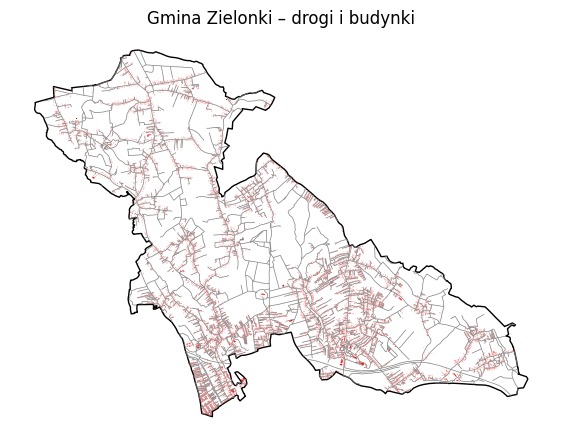

In [13]:
# podgląd danych na mapie - dorgi i budynki przycięte do granic wybranej gminy 

fig, ax = plt.subplots(figsize=(7, 7))
gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
drogi_gmina.plot(ax=ax, color="gray", linewidth=0.5)
budynki_gmina.plot(ax=ax, color="red", markersize=1)
ax.set_title(f"Gmina {nazwa_gminy} – drogi i budynki")
ax.set_axis_off()
plt.show()

### Centroid 
Centroid to punkt reprezentujący „środek” geometrii (poligonu, linii, wielokąta złożonego).​  

- Dla poligonu centroid jest środkiem ciężkości kształtu – zwykle znajduje się „mniej więcej w środku” obszaru, ale niekoniecznie na środku boków.

- Dla linii centroid leży mniej więcej w połowie jej długości, a dla punktu centroid to po prostu ten sam punkt.​

- W GeoPandas centroid liczymy przez gdf.geometry.centroid (dla całej kolumny) albo geom.centroid (dla pojedynczej geometrii).​


POINT (570492.6901267928 243344.10745371936)


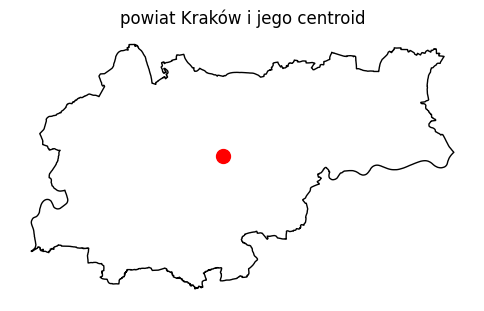

In [14]:
# powiaty["JPT_NAZWA_"].value_counts()
powiaty.head()

kolumna_powiat = "JPT_NAZWA_"
powiat_name = "powiat Kraków"

powiat_sel = powiaty[powiaty[kolumna_powiat] == powiat_name]

# iloc[0] wybiera geometrię jednego wiersza a centroid liczy centorid 
centroid_geom = powiat_sel.geometry.iloc[0].centroid
print(centroid_geom)

# tworzymy GeoDataFrame dla centroidu 
centroid_gdf = gpd.GeoDataFrame(geometry=[centroid_geom], crs=powiat_sel.crs)
centroid_gdf.head()

# wizualizacja - powiat i jego centroid 
fig, ax = plt.subplots(figsize=(6, 6))

powiat_sel.plot(ax=ax, facecolor="none", edgecolor="black")
centroid_gdf.plot(ax=ax, color="red", markersize=100)  # duża kropka

ax.set_title(f"{powiat_name} i jego centroid")
ax.set_axis_off()
plt.show()



### Funkcje union/intersection/difference  

Tworzymy duży bufor wokół centroidu powiatu aby porównać funkcje union/intersection/difference  



In [15]:
# bufor wokół centroidu
promien_bufora = 9_000  # 9 km
bufor_centroidu = centroid_gdf.buffer(promien_bufora)
bufor_centroidu = gpd.GeoDataFrame(geometry=bufor_centroidu, crs=powiat_sel.crs)

In [16]:
union = gpd.overlay(powiat_sel, bufor_centroidu, how="union")
intersection = gpd.overlay(powiat_sel, bufor_centroidu, how="intersection")
difference = gpd.overlay(powiat_sel, bufor_centroidu, how="difference")

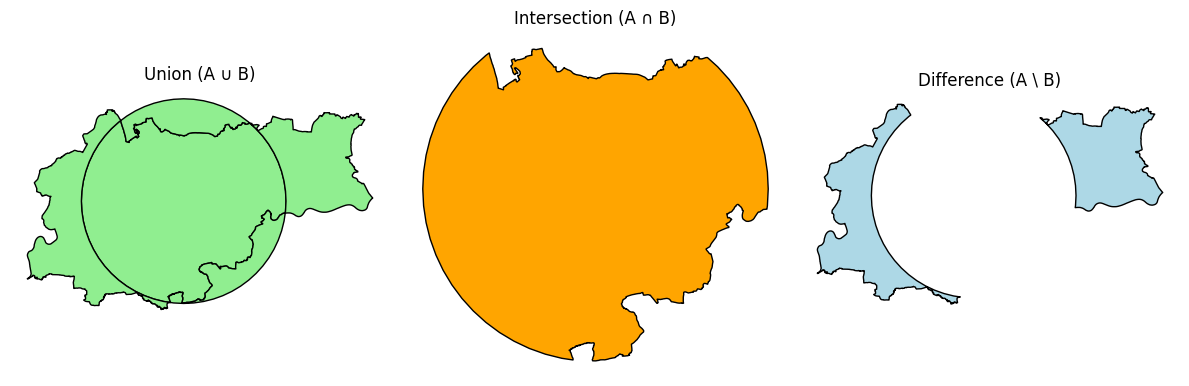

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

union.plot(ax=axes[0], facecolor="lightgreen", edgecolor="black")
axes[0].set_title("Union (A ∪ B)")

intersection.plot(ax=axes[1], facecolor="orange", edgecolor="black")
axes[1].set_title("Intersection (A ∩ B)")

difference.plot(ax=axes[2], facecolor="lightblue", edgecolor="black")
axes[2].set_title("Difference (A \\ B)")

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

### Bufor 
Buffer tworzy strefę o zadanym promieniu wokół geometrii (punktu, linii, poligonu) w jednostkach układu współrzędnych (w metrach, jeśli CRS jest metryczny).

Wynik: obiekty typu POLYGON – pas o zadanej szerokości po obu stronach obiektu. 

Jeśli chcemy z wielu buforów zrobić jeden ciągły poligon („rozlać” wszystko w jedną strefę), używamy unary_union. unary_union łączy wszystkie bufory w jedną geometrię (lub kilka, jeśli się nie stykają).


In [18]:
# chcemy wykonać bufor dla głównych dróg w gminie Zielonki 

# sprawdzamy jakie atrybuty ma zbiór drogi, aby znaleźć kategorię dróg 
print(drogi_gmina.columns)

# zakładam że kolumna "KLASADROGI" odpowiada kategoriom 
# wybieram klasę (selekcja po atrybutach na początku notebooka)
klasa_glowna = "droga główna"
drogi_glowne = drogi_gmina[drogi_gmina["KLASADROGI"] == klasa_glowna]
drogi_glowne.head()

Index(['TERYT', 'LOKALNYID', 'PRZESTRZENNAZW', 'WERSJA',
       'POCZATEKWERSJIOBIEKTU', 'OZNACZENIEZMIANY',
       'ZRODLODANYCHGEOMETRYCZNYCH', 'KATEGORIAISTNIENIA', 'UWAGI',
       'INFORMACJADODATKOWA', 'KODKARTO10K', 'SKROTKARTOGRAFICZNY',
       'KATEGORIAZARZADZANIA', 'KLASADROGI', 'MATERIALNAWIERZCHNI',
       'NAZWADROGI', 'LICZBAJEZDNIDROGI', 'POLOZENIE', 'SZEROKOSCNAWIERZCHNI',
       'NUMERDROGI', 'gml_id', 'gml_id_1', 'JPT_SJR_KO_1', 'JPT_POWIER_1',
       'JPT_KOD_JE_1', 'JPT_NAZWA__1', 'JPT_JOR_ID_1', 'WERSJA_OD_1',
       'WAZNY_OD_1', 'JPT_ORGAN1_1', 'JPT_WAZNA__1', 'IIP_PRZEST_1',
       'IIP_IDENTY_1', 'IIP_WERSJA_1', 'JPT_KJ_IIP_1', 'JPT_KJ_I_1_1',
       'JPT_SPS_KO_1', 'JPT_ID_1', 'REGON_1', 'gml_id_2', 'JPT_SJR_KO_2',
       'JPT_POWIER_2', 'JPT_KOD_JE_2', 'JPT_NAZWA__2', 'JPT_JOR_ID_2',
       'WERSJA_OD_2', 'WAZNY_OD_2', 'JPT_ORGAN1_2', 'JPT_WAZNA__2',
       'IIP_PRZEST_2', 'IIP_IDENTY_2', 'IIP_WERSJA_2', 'JPT_KJ_IIP_2',
       'JPT_KJ_I_1_2', 'JPT_SPS_KO_2', 

,TERYT,LOKALNYID,PRZESTRZENNAZW,WERSJA,POCZATEKWERSJIOBIEKTU,OZNACZENIEZMIANY,ZRODLODANYCHGEOMETRYCZNYCH,KATEGORIAISTNIENIA,UWAGI,INFORMACJADODATKOWA,...,JPT_WAZNA__2,IIP_PRZEST_2,IIP_IDENTY_2,IIP_WERSJA_2,JPT_KJ_IIP_2,JPT_KJ_I_1_2,JPT_SPS_KO_2,JPT_ID_2,REGON_2,geometry
12,1206,28BEDBBB-B94D-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"LINESTRING (563767.07 253998.06, 563761.84 254..."
14,1206,28BEDBBB-F910-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"LINESTRING (563561.56 257322.47, 563558.99 257..."
53,1206,28BEDBBB-B95E-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"LINESTRING (565602.41 251622.53, 565574.43 251..."
68,1206,28BEDBBB-BC59-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"LINESTRING (564851.82 252179.07, 564846.02 252..."
85,1206,28BEDBBB-BA3A-4344-E053-CA2BA8C083FA,PL.PZGiK.283.BDOT10k,2023-12-31 12:00:00,2023-12-31 12:00:00,GI-TOPO.600.116.2023,ortofotomapa,eksploatowany,NaN,NaN,...,NZN,PL.PZGIK.200,3104c00e-f86d-4d1a-ac9e-8c85e101ac95,2026-02-24T10:28:06,EGIB,1206.0,UZG,10012119,35155441300000,"LINESTRING (564202.11 255543.64, 564202.56 255..."


In [19]:
bufor_150m = drogi_glowne.buffer(150)  # 150 m – jednostki CRS
bufor_union = bufor_150m.union_all()  # jeden poligon
bufor_150m_gdf = gpd.GeoDataFrame(geometry=[bufor_union], crs=drogi_glowne.crs)

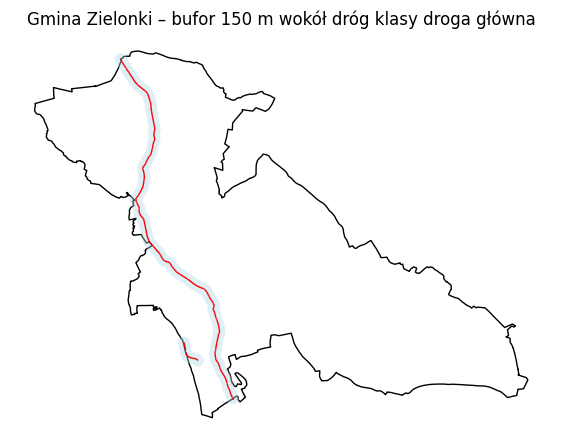

In [20]:
# podgląd bufora na mapie

fig, ax = plt.subplots(figsize=(7, 7))

gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
bufor_150m_gdf.plot(ax=ax, facecolor="lightblue", alpha=0.4)
drogi_glowne.plot(ax=ax, color="red", linewidth=1)

ax.set_title(f"Gmina {nazwa_gminy} – bufor 150 m wokół dróg klasy {klasa_glowna}")
ax.set_axis_off()
plt.show()


In [21]:
# sprawdzenie ile budynków miesci się w buforze a ile poza dla wybranej gminy

budynki_w_buforze = gpd.overlay(budynki_gmina, bufor_150m_gdf, how="intersection")
print("Liczba budynków w buforze 150 m:", len(budynki_w_buforze))

budynki_poza_buforem = gpd.overlay(budynki_gmina, bufor_150m_gdf, how="difference")
print("Liczba budynków poza buforem:", len(budynki_poza_buforem))

Liczba budynków w buforze 150 m: 1551
Liczba budynków poza buforem: 10884


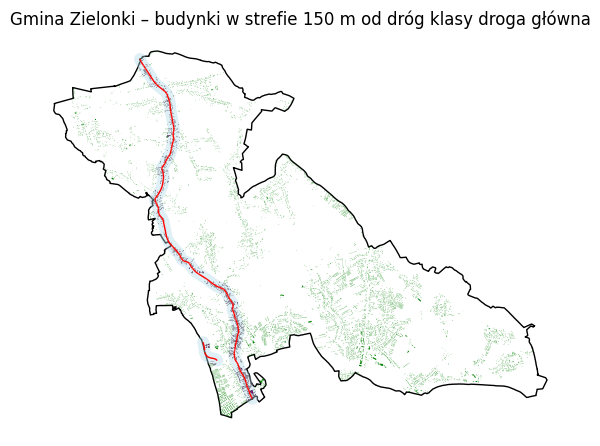

In [22]:
# wizualizacja: mapa dla gminy Zielonki z drogą główną, buforem oraz budynkami

fig, ax = plt.subplots(figsize=(7, 7))

gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
bufor_150m_gdf.plot(ax=ax, facecolor="lightblue", alpha=0.4)
drogi_glowne.plot(ax=ax, color="red", linewidth=1)

# wszystkie budynki – jasno
budynki_gmina.plot(ax=ax, color="green", markersize=1)

# budynki w buforze – wyróżnione
budynki_w_buforze.plot(ax=ax, color="purple", markersize=1)

ax.set_title(f"Gmina {nazwa_gminy} – budynki w strefie 150 m od dróg klasy {klasa_glowna}")
ax.set_axis_off()
plt.show()


# Zadania

Ćwiczenie 1. Długość dróg każdej klasy w wybranej gminie
1. Wybierz dowolną gminę po nazwie (z powiatu krakowskiego).
2. Przytnij warstwę dróg do tej gminy.
3. Oblicz długość dróg (w kilometrach) dla każdej klasy (KLASADROGI).
4. Zapisz wyniki w postaci tabeli (np. DataFrame) i narysuj prosty wykres słupkowy.

Podpowiedź:
- użyj groupby("KLASA_DROGI")["length_m"].sum() i podziel przez 1000.


In [23]:
wybrana_gmina = "Liszki"

gmina_sel = gminy[gminy["JPT_NAZWA__1"] == wybrana_gmina]

drogi_gmina = gpd.overlay(drogi, gmina_sel, how="intersection")
budynki_gmina = gpd.overlay(budynki, gmina_sel, how="intersection")

print("Liczba odcinków dróg w gminie:", len(drogi_gmina))
print("Liczba budynków w gminie:", len(budynki_gmina))

Liczba odcinków dróg w gminie: 3400
Liczba budynków w gminie: 10723


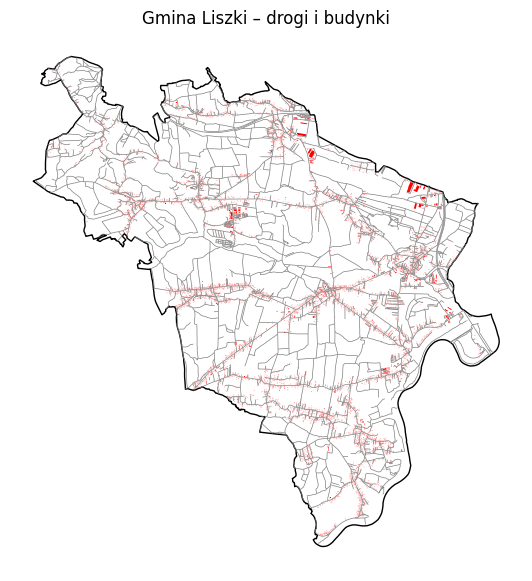

In [24]:
fig, ax = plt.subplots(figsize=(7, 7))
gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
drogi_gmina.plot(ax=ax, color="gray", linewidth=0.5)
budynki_gmina.plot(ax=ax, color="red", markersize=1)
ax.set_title(f"Gmina {wybrana_gmina} – drogi i budynki")
ax.set_axis_off()
plt.show()

In [25]:
drogi_gmina["length_m"] = drogi_gmina.geometry.length
dlugosc_drog = drogi_gmina.groupby("KLASADROGI")["length_m"].sum() / 1000
dlugosc_drog

KLASADROGI
autostrada            8.009714
droga dojazdowa       0.546789
droga główna         10.878764
droga lokalna        34.306448
droga wewnętrzna    416.198532
droga zbiorcza       27.627793
Name: length_m, dtype: float64

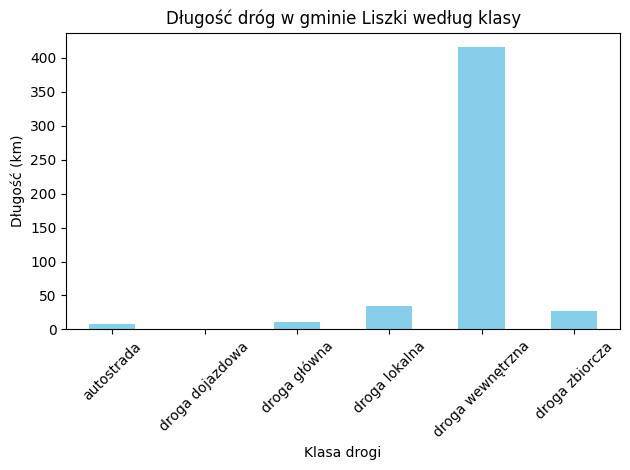

In [26]:
dlugosc_drog.plot(kind="bar", color="skyblue")
plt.title(f"Długość dróg w gminie {wybrana_gmina} według klasy")
plt.xlabel("Klasa drogi")
plt.ylabel("Długość (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ćwiczenie 2. Które budynki znajdują się w pobliżu dróg głównych?

Zakładamy, że interesują nas budynki położone blisko dróg wybranej klasy (np. dróg głównych).
1. Wybierz gminę.
2. W warstwie dróg wybierz tylko jedną klasę (np. KLASA_DROGI == "G").
3. Utwórz bufor np. 30 m wokół tych dróg (przetestuj różne).
4. Sprawdź, które budynki przecinają się z buforem (intersection).
5. Narysuj mapę:
    - tło: granica gminy,
    - wszystkie drogi (np. szare),
    - drogi wybranej klasy (np.zielone),
    - wszystkie budynki (np. szare),
    - budynki w buforze (np. pomarańczowe).
6. Policz, ile budynków jest w buforze oraz jaki procent wszystkich budynków w gminie one stanowią.
7. Wyeksportuj drogę, bufor drogi oraz budynki wewnątrz bufora do pliku i otwórz je w programie QGIS. Porównaj z danymi źródłowymi.

In [27]:
drogi_gmina["KLASADROGI"].unique()

<StringArray>
['droga wewnętrzna',    'droga lokalna',   'droga zbiorcza',
     'droga główna',       'autostrada',  'droga dojazdowa']
Length: 6, dtype: str

In [28]:
wybrane_drogi = drogi_gmina[drogi_gmina["KLASADROGI"] == "droga zbiorcza"]
drogi_bufor = wybrane_drogi.buffer(30)
drogi_bufor_gdf = gpd.GeoDataFrame(geometry=drogi_bufor, crs=wybrane_drogi.crs)
budynki_w_buforze = gpd.sjoin(budynki_gmina, drogi_bufor_gdf, how="inner", predicate="intersects")

<Axes: >

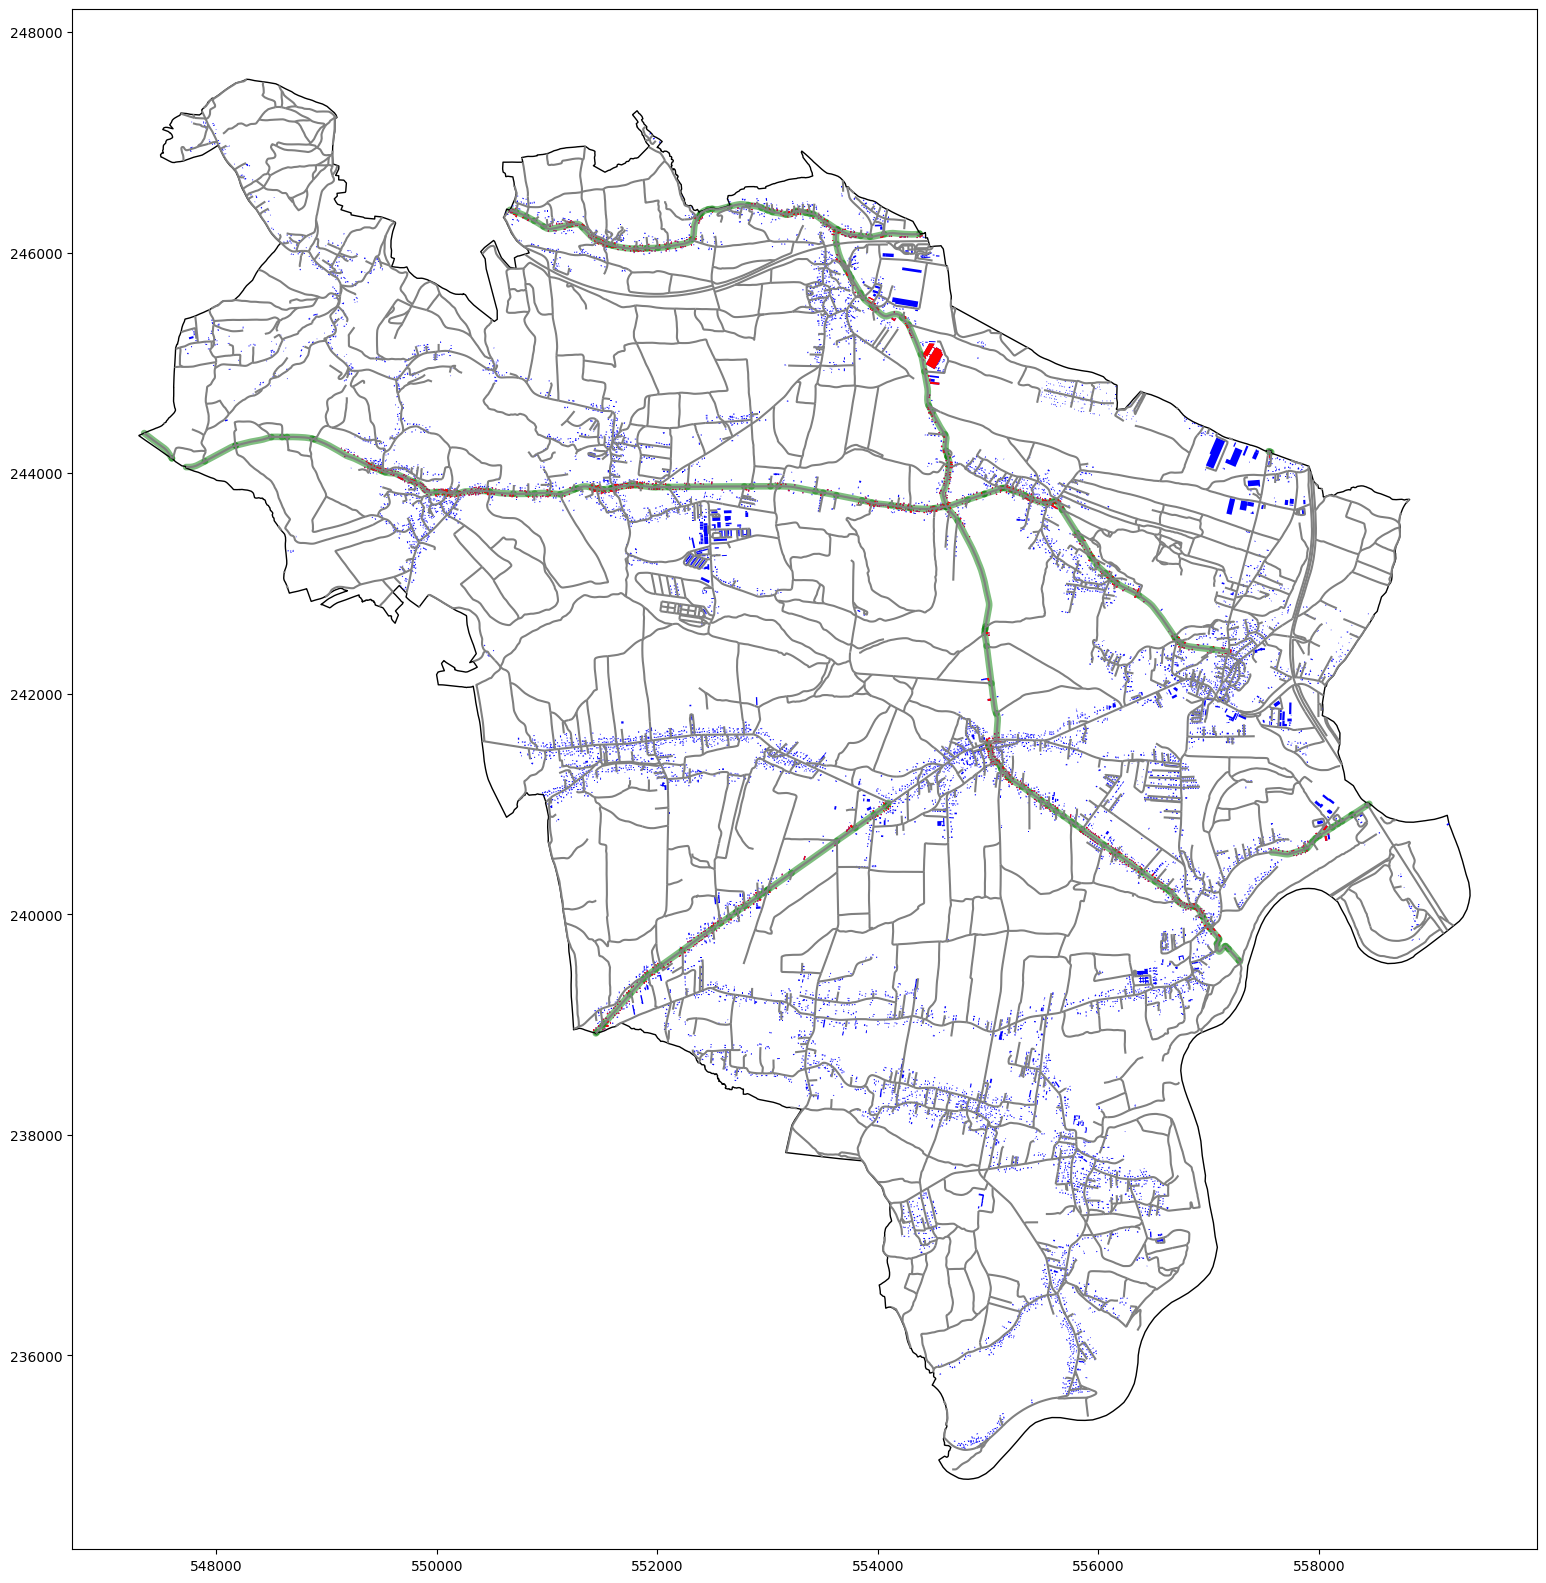

In [29]:
fig, ax = plt.subplots(figsize=(20, 20))
drogi_bufor.plot(ax=ax, color="green", alpha=0.5)
gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
drogi_gmina.plot(ax=ax, color="gray")
budynki_gmina.plot(ax=ax, color="blue")
budynki_w_buforze.plot(ax=ax, color="red")

In [30]:
f"Budynki w buforze: {len(budynki_w_buforze)} / {len(budynki_gmina)} ({(len(budynki_w_buforze) / len(budynki_gmina)) * 100:.0f}%)"

'Budynki w buforze: 1713 / 10723 (16%)'

In [31]:
budynki_w_buforze.to_file("budynki_w_buforze.gpkg", driver="GPKG")
wybrane_drogi.to_file("drogi_zbiorcze.gpkg", driver="GPKG")
drogi_bufor_gdf.to_file("bufor_drog_zbiorczych.gpkg", driver="GPKG")

Ćwiczenie 3. Porównanie wpływu dwóch klas dróg na zabudowę
1. Wybierz gminę.
2. Wybierz dwie różne klasy dróg (np. jedna „główna”, jedna „lokalna”).
3. Dla każdej klasy:
    - utwórz bufor (np. 100 m),
    - znajdź budynki w tym buforze,
    - policz łączną powierzchnię zabudowy w buforze (km²).
4. Porównaj, która klasa dróg „ma wokół siebie” więcej zabudowy.
5. Zrób mapę z dwiema strefami buforów w różnych kolorach.

Powierzchnia zabudowy w buforze droga główna: 0.19 km²
Powierzchnia zabudowy w buforze droga lokalna: 0.33 km²


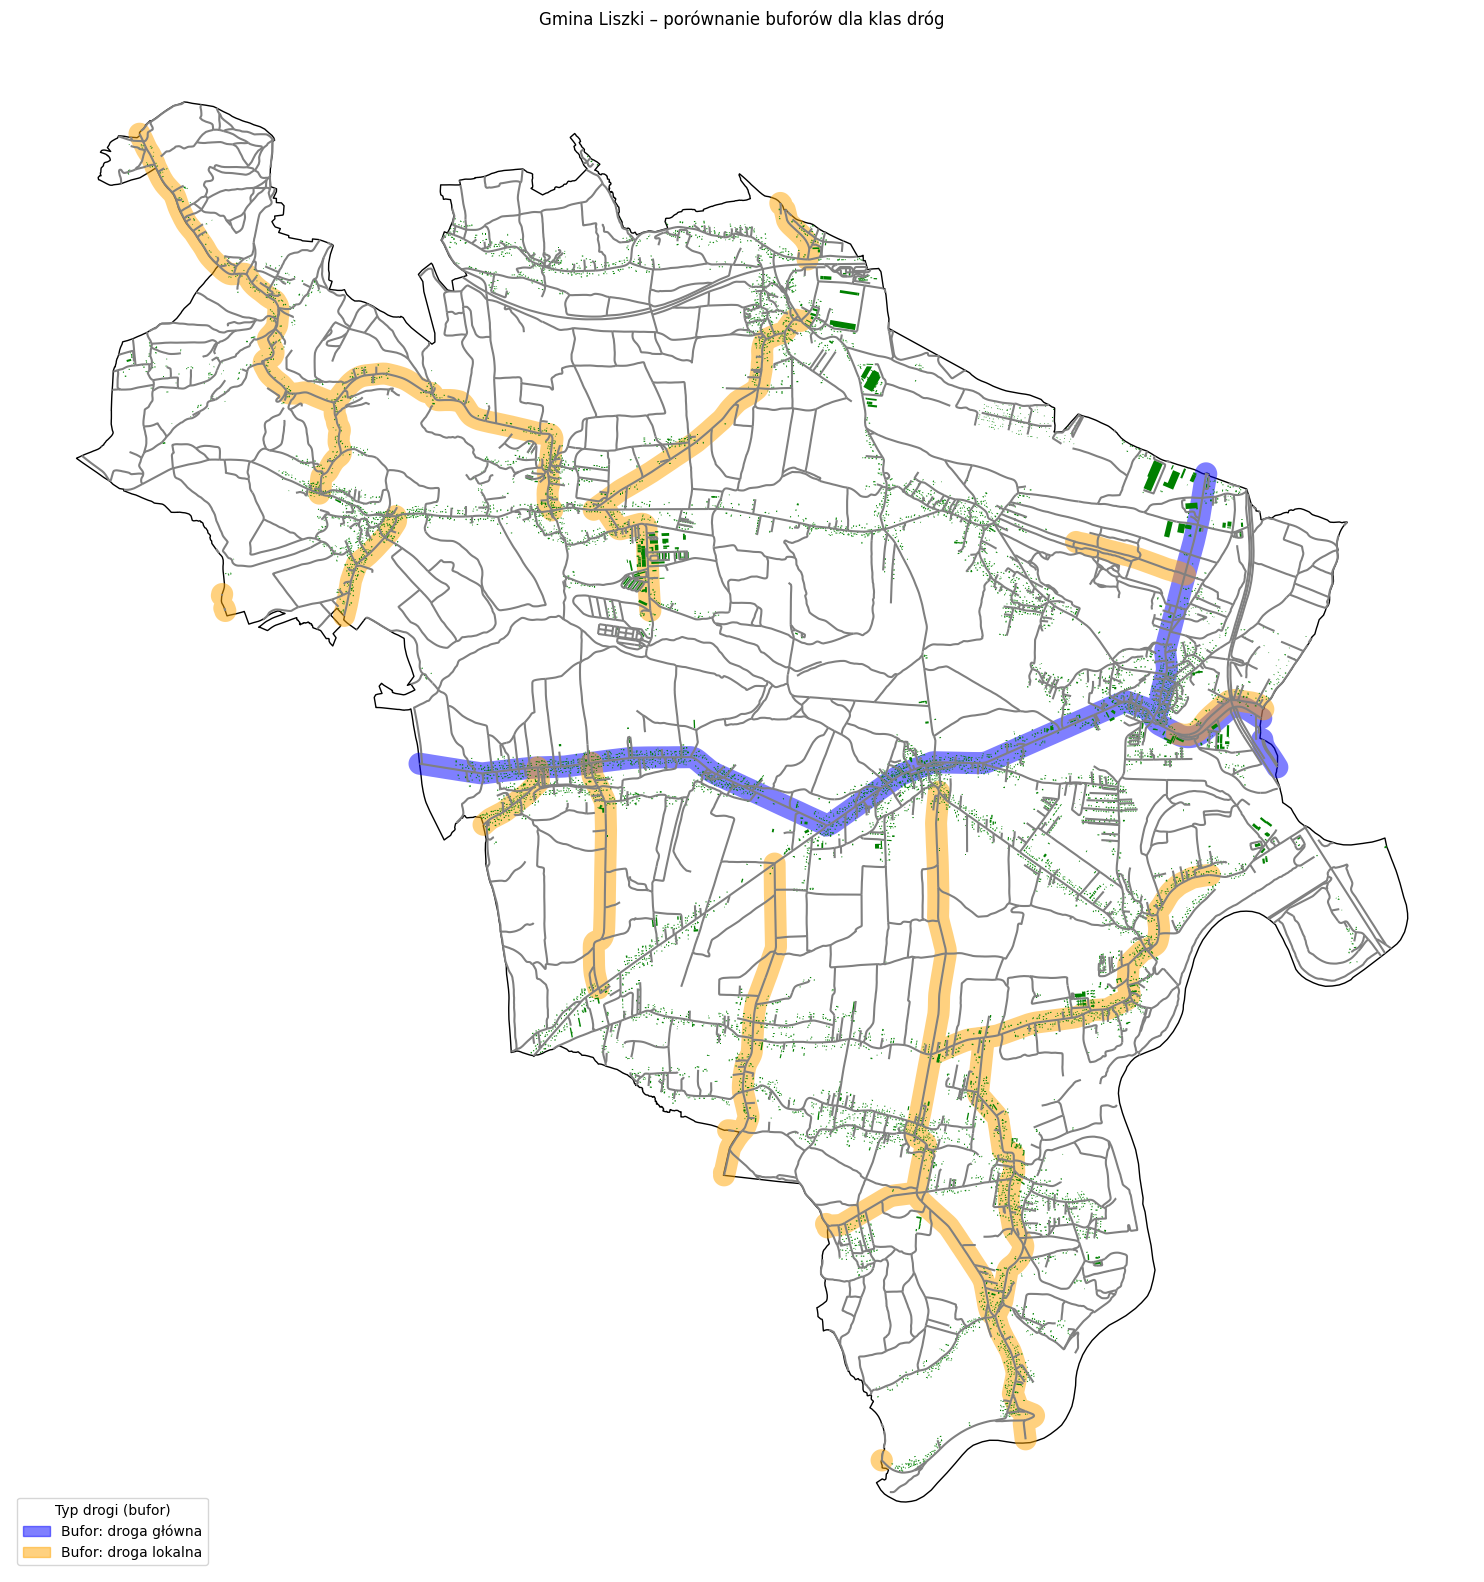

In [32]:
from matplotlib.patches import Patch

wybrana_gmina = "Liszki"
gmina_sel = gminy[gminy["JPT_NAZWA__1"] == wybrana_gmina]
drogi_gmina = gpd.overlay(drogi, gmina_sel, how="intersection")
budynki_gmina = gpd.overlay(budynki, gmina_sel, how="intersection")

klasa1 = "droga główna"
klasa2 = "droga lokalna"

drogi_klasa1 = drogi_gmina[drogi_gmina["KLASADROGI"] == klasa1]
drogi_klasa2 = drogi_gmina[drogi_gmina["KLASADROGI"] == klasa2]

bufor_klasa1_geom = drogi_klasa1.buffer(100).union_all()
bufor_klasa2_geom = drogi_klasa2.buffer(100).union_all()

bufor_klasa1_gdf = gpd.GeoDataFrame(geometry=[bufor_klasa1_geom], crs=drogi_klasa1.crs)
bufor_klasa2_gdf = gpd.GeoDataFrame(geometry=[bufor_klasa2_geom], crs=drogi_klasa2.crs)

budynki_klasa1 = gpd.sjoin(budynki_gmina, bufor_klasa1_gdf, how="inner", predicate="intersects")
budynki_klasa2 = gpd.sjoin(budynki_gmina, bufor_klasa2_gdf, how="inner", predicate="intersects")

powierzchnia_klasa1 = budynki_klasa1.geometry.area.sum() / 1e6
powierzchnia_klasa2 = budynki_klasa2.geometry.area.sum() / 1e6

print(f"Powierzchnia zabudowy w buforze {klasa1}: {powierzchnia_klasa1:.2f} km²")
print(f"Powierzchnia zabudowy w buforze {klasa2}: {powierzchnia_klasa2:.2f} km²")

fig, ax = plt.subplots(figsize=(20, 20))
gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
bufor_klasa1_gdf.plot(ax=ax, color="blue", alpha=0.5)
bufor_klasa2_gdf.plot(ax=ax, color="orange", alpha=0.5)
drogi_gmina.plot(ax=ax, color="gray")
budynki_gmina.plot(ax=ax, color="green")

legend_elements = [
    Patch(facecolor="blue", edgecolor="blue", alpha=0.5, label=f"Bufor: {klasa1}"),
    Patch(facecolor="orange", edgecolor="orange", alpha=0.5, label=f"Bufor: {klasa2}")
]
ax.legend(handles=legend_elements, title="Typ drogi (bufor)", loc="lower left")

ax.set_title(f"Gmina {wybrana_gmina} – porównanie buforów dla klas dróg")
ax.set_axis_off()
plt.show()

## Dla chętnych 

Spróbuj ulepszyć wizualizacje, np za pomocą leaflet: https://ipyleaflet.readthedocs.io/en/latest/ i dodania warstw bazowych (open street map). Możesz dodać ładniejsze kolory, legendy, zoom na szczególne miejsca ...   
UWAGA: leaflet nie działa na VSCode - można otworzyć w jupyter notebook przez stronę lub w google colab

In [38]:
from ipyleaflet import Map, GeoJSON, LayersControl
import json


def gdf_to_geojson_wgs84(gdf):
    gdf2 = gdf.copy()
    if gdf2.crs is None:
        raise ValueError("GeoDataFrame bez CRS")
    if gdf2.crs.to_epsg() != 4326:
        gdf2 = gdf2.to_crs(4326)
    return json.loads(gdf2.to_json(default=str))


gmina_wgs84 = gmina_sel.to_crs(4326)
drogi_wgs84 = drogi_gmina.to_crs(4326)
budynki_wgs84 = budynki_gmina.to_crs(4326)

gmina_layer = GeoJSON(
    data=gdf_to_geojson_wgs84(gmina_wgs84),
    style={"color": "black", "weight": 2, "fillOpacity": 0}
)
drogi_layer = GeoJSON(
    data=gdf_to_geojson_wgs84(drogi_wgs84),
    style={"color": "gray", "weight": 2}
)
budynki_layer = GeoJSON(
    data=gdf_to_geojson_wgs84(budynki_wgs84),
    style={"color": "red", "weight": 1, "fillOpacity": 0.4}
)

pt = gmina_wgs84.geometry.union_all().representative_point()
center = [pt.y, pt.x]

m = Map(center=center, zoom=12)
m.add(gmina_layer)
m.add(drogi_layer)
m.add(budynki_layer)
m.add(LayersControl())

minx, miny, maxx, maxy = gmina_wgs84.total_bounds
m.fit_bounds(((miny, minx), (maxy, maxx)))

m

Map(center=[50.036114573370476, 19.759103169697205], controls=(ZoomControl(options=['position', 'zoom_in_text'…